## Langgraph APIs

LangGraph provides two different APIs to build agent workflows: the **Graph API** and the **Functional API**.

Both APIs share the same underlying runtime and can be used together in the same application, but they are designed for different use cases and development preferences.

Use the Graph API when you need:
- **Complex workflow** visualization for debugging and documentation
- **Explicit state management** with shared data across multiple nodes
- **Conditional branching** with multiple decision points
- **Parallel execution paths** that need to merge later
- **Team collaboration** where visual representation aids understanding

Use the Functional API when you want:
- **Minimal code changes** to existing procedural code
- **Standard control flow** (if/else, loops, function calls)
- **Function-scoped state** without explicit state management
- **Rapid prototyping** with less boilerplate
- **Linear workflows** with simple branching logic



### Using GRAPH-API
The Graph API uses a declarative approach where you define nodes, edges, and shared state to create a visual graph structure.

- Nodes => Functionality or some generator function
- Edges => That carries inputs or passes some intermediate values to the next Node
- State => Variables that holds the output or value generated from the Node.

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class MsgState(TypedDict): 
    # TypedDict is simple run-time dictionary where we can store values as key value pairs just like Objects in JavaScript.
    # So MsgState becomes a custom dictionary. So by using class keyword we can create a Blueprint/Schema for our Dictionary. 
    # By using TypedDict to this custom dictionary (MsgState) I have created a blueprint that stores enforces what keys will be stored, similar to JS Objects and keys.
    
    messages: Annotated[list, add_messages] #This is a key


In [ ]:
# Now we'll build the Entire Graph

import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
from langchain_google_genai import ChatGoogleGenerativeAI

# Defining LLM has two types
# Type1:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash")
llm



In [ ]:
#Type2:
llm2 = init_chat_model("google_genai:gemini-2.5-flash-lite")
llm2

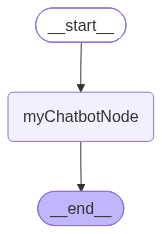

In [19]:
# Now Node of the State Graph is to be defined
# Nodes are actually function definition that returns some predefined output in a proper format

def myChatBot(MsgState: MsgState):
    return {"messages": [llm.invoke(MsgState["messages"])]} #"messages" is a key word in class MsgType dictionary

# Now Need to build graph. I need one Node, one start, one end with in-between edges for simple one node chatbot
graph_builder = StateGraph(MsgState)

graph_builder.add_edge(START, "myChatbotNode")
graph_builder.add_node("myChatbotNode", myChatBot)
graph_builder.add_edge("myChatbotNode", END)

# Need to compile this graph
myGraph = graph_builder.compile()

# Visualize the Graph
from IPython.display import Image, display

try:
    display(Image(myGraph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [ ]:
# Now Invoke the Graph to send and receive msg
response = myGraph.invoke({"messages": "Hi"})

#Print the Response from the LLM
response["messages"][-1].content


In [ ]:
# Stream the output response
for event in myGraph.stream({"messages": "How are you man?"}):
    for value in event.values():
        print(value["messages"][-1].content)

**Annotated[list, add_messages]**: This describes the type and behaviour of the **messages** key.

- **list**: Specifies that the data stored here must be a list of messages.
- **add_messages**: This is a **reducer** function from the LangGraph. Instead of replacing the existing list of messages when a new one arrives, **add_messages** tells LangGraph to **append/merge** the new messages to the existing list, automatically building your chat history.

**What is Annotated?**
- In Python it is a **type-hinting** tool. 
- It lets you attach **extra metadata** to the data type.

- Syntax: ```Annotated[Type, Metadata]```
- My case: ```Annotated[list, add_messages]```

I have used it here to define two things at once for the key `messages`:

1. **The Type (list)**: Tells Python's type checker that it is a list.
2. **The Metadata (add_messages)**: Tells LangGraph at the run-time to use the `add_messages` function to **append** new messages instead of replacing/overwriting them.


## Node Explanation for **MyChatBot**:

```python
def myChatBot(state: MsgState):
    return {"messages": [llm.invoke(MsgState["messages"])]}

```

- Here my input is : `MsgState["messages"]`
- I am passing this input to LLM: `llm.invoke(MsgState["messages"])`
- The output is appended in `messages` keyword of the same class as input class `MsgState`.